# Insurance Policy Explainer Agent – Certification Project Roadmap

Perfect, I’ll act as a Product Manager + AI Solutions Engineer and give you a Cursor-coder–ready, end-to-end task roadmap that satisfies every criterion listed.

PROJECT NAME 
Insurance Policy Explainer & Claim Readiness Agent

FINAL TASK ROADMAP
1. Problem + Audience
2. Solution
3. Data + Keys
4. Prototype
5. Eval Baseline
6. Retriever Upgrade
7. Demo Day Readiness



## Task 1: Getting Dependencies!

In [36]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

In [37]:
if not os.environ.get("COHERE_API_KEY"):
    os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

In [38]:
# Core imports we'll use throughout the notebook
import os
import getpass
from uuid import uuid4

import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

In [39]:
# Set up LangSmith for tracing

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE9 - The Agent Loop - {uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key (press Enter to skip): ") or ""

if not os.environ["LANGCHAIN_API_KEY"]:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("LangSmith tracing disabled")
else:
    print(f"LangSmith tracing enabled. Project: {os.environ['LANGCHAIN_PROJECT']}")

LangSmith tracing enabled. Project: AIE9 - The Agent Loop - bb0010e4


In [40]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass(
        "Enter your Tavily API Key: "
    )

## Task 2: Data Collection and Preparation

In [41]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Resolve PDF path: try project root (cwd or parent when running from notebooks/)
_data_dir = Path("data")
if not _data_dir.exists():
    _data_dir = Path.cwd().parent / "data"
_pdf_path = _data_dir / "health_benefits_and_coverage.pdf"
if _pdf_path.exists():
    pdf_source = str(_pdf_path)
else:
    # Fallback: public CMS SBC sample PDF so the notebook runs without a local file
    pdf_source = "https://www.cms.gov/CCIIO/Resources/Regulations-and-Guidance/Downloads/SBC-Sample-Completed.pdf"

loader = PyPDFLoader(pdf_source)
raw_docs = loader.load()   # returns list[Document]

# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

health_benefits_docs = text_splitter.split_documents(raw_docs)

print(f"Loaded {len(raw_docs)} pages")
print(f"Created {len(health_benefits_docs)} chunks")

Loaded 5 pages
Created 32 chunks


In [42]:
print(f"Raw documents: {len(raw_docs)}")
print(f"Split chunks: {len(health_benefits_docs)}")
print(f"\nExample chunk:\n{health_benefits_docs[0]}")

Raw documents: 5
Split chunks: 32

Example chunk:
page_content='Summary of Benefits and Coverage: What this Plan Covers & What You Pay For Covered Services Coverage Period: 1/1/2017 – 12/31/2017 
Insurance Company 1: Plan Option 1 Coverage for: Family | Plan Type: PPO 
The Summary of Benefits and Coverage (SBC) document will help you choose a health plan. The SBC shows you how you and the plan would 
 
Important Questions Answers Why This Matters: 
What is the overall 
deductible?' metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Acrobat PDFMaker 15 for Word', 'creationdate': '2016-02-24T13:08:31-05:00', 'author': 'CMS', 'company': 'EBSA', 'keywords': '•\tPlan document, summary of benefits and coverage, health coverage, SBC, plan information', 'moddate': '2016-02-24T14:50:42-05:00', 'sourcemodified': 'D:20160222192427', 'subject': 'SBC Sample Completed', 'title': 'SBC Sample Completed', '_adhocreviewcycleid': '-1319521634', '_authoremail': 'Michelle.Koltov@cms.hhs.gov', '_au

## Task 3: Setting up vector store

In [43]:
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vectorstore = QdrantVectorStore.from_documents(
    health_benefits_docs,
    embeddings,
    location=":memory:",
    collection_name="health_benefits_guide",
)

## Task 4: Define tools

In [44]:
import os
from typing import List, TypedDict
from tavily import TavilyClient
from langchain_core.tools import tool

tavily_client = TavilyClient(
    api_key=os.environ.get("TAVILY_API_KEY")
)

class PublicSearchResult(TypedDict):
    query: str
    answer: str
    sources: List[str]
    confidence: str

@tool
def public_insurance_search(
    query: str,
    location: str = "Texas",
    year: int = 2026
) -> PublicSearchResult:
    """
    Fetch up-to-date, publicly available insurance information
    when internal RAG knowledge is insufficient.
    """

    enriched_query = (
        f"{query} public insurance programs {location} {year} "
        f"official government or trusted sources"
    )

    results = tavily_client.search(
        query=enriched_query,
        max_results=5,
        include_answer=True,
        include_sources=True
    )

    return {
        "query": enriched_query,
        "answer": results.get("answer", "").strip(),
        "sources": results.get("sources", []),
        "confidence": "medium" if results.get("answer") else "low"
    }

tools = [public_insurance_search]

print("Tools created:")
for t in tools:
    print(f"  - {t.name}: {t.description[:60]}...")

Tools created:
  - public_insurance_search: Fetch up-to-date, publicly available insurance information
w...


#### Task 5: Build health_agent (LangGraph)

Orchestrates RAG (naive_retrieval_chain) then optionally Tavily via a router. Run this cell after the naive LCEL chain above.

In [70]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage

# State: question, RAG output, and optional Tavily result
class AgentState(TypedDict):
    question: str
    rag_context: str
    rag_response: str
    tavily_result: str
    messages: list

llm = ChatOpenAI(model="gpt-4o")

# --- Node: RAG first (use naive_retrieval_chain from earlier cells) ---
def rag_node(state: AgentState) -> dict:
    out = naive_retrieval_chain.invoke({"question": state["question"]})
    context = "\n\n".join(d.page_content for d in out["context"])
    response = out["response"].content if hasattr(out["response"], "content") else str(out["response"])
    return {"rag_context": context, "rag_response": response}

# --- Node: should_continue — decide if we need Tavily ---
CONTINUE_PROMPT = """Given the user question and the RAG answer from internal documents, decide if we need to search the public web (Tavily).
Use Tavily only if: the RAG answer says it doesn't know, is unsure, or the question clearly needs current/public info (e.g. latest rates, recent policy changes).
Reply with exactly one word: continue (need Tavily) or end (RAG answer is sufficient).

User question: {question}
RAG answer: {rag_response}

Your one-word reply:"""

def should_continue_node(state: AgentState) -> dict:
    prompt = CONTINUE_PROMPT.format(question=state["question"], rag_response=state["rag_response"])
    msg = llm.invoke([HumanMessage(content=prompt)])
    text = msg.content.strip().lower() if hasattr(msg, "content") else str(msg).lower()
    decision = "continue" if "continue" in text else "end"
    return {"messages": state.get("messages", []) + [AIMessage(content=decision)]}

def should_continue_route(state: AgentState) -> Literal["tavily", "respond"]:
    last = state["messages"][-1] if state.get("messages") else None
    if last and hasattr(last, "content") and "continue" in (last.content or "").lower():
        return "tavily"
    return "respond"

# --- Node: call Tavily via the existing tool ---
def tavily_node(state: AgentState) -> dict:
    result = public_insurance_search.invoke({"query": state["question"]})
    text = result.get("answer", "") or str(result)
    return {"tavily_result": text}

# --- Node: final response (RAG only or RAG + Tavily) ---
RESPOND_PROMPT = """You are an insurance and health benefits assistant. Be faithful to sources.

User question: {question}

Answer from internal policy documents (RAG):
{rag_response}
{tavily_section}

Provide a clear, helpful final answer. If you used both RAG and web search, say so and combine only when consistent."""

def respond_node(state: AgentState) -> dict:
    tavily_section = ""
    if state.get("tavily_result"):
        tavily_section = "\n\nAdditional public/web information:\n" + state["tavily_result"]
    prompt = RESPOND_PROMPT.format(
        question=state["question"],
        rag_response=state["rag_response"],
        tavily_section=tavily_section,
    )
    msg = llm.invoke([HumanMessage(content=prompt)])
    final = msg.content if hasattr(msg, "content") else str(msg)
    return {"messages": state.get("messages", []) + [AIMessage(content=final)]}

# --- Build graph ---
graph = StateGraph(AgentState)
graph.add_node("rag", rag_node)
graph.add_node("should_continue", should_continue_node)
graph.add_node("tavily", tavily_node)
graph.add_node("respond", respond_node)

graph.add_edge(START, "rag")
graph.add_edge("rag", "should_continue")
graph.add_conditional_edges("should_continue", should_continue_route, {"tavily": "tavily", "respond": "respond"})
graph.add_edge("tavily", "respond")
graph.add_edge("respond", END)

health_agent = graph.compile()

print("Agent created successfully (LangGraph: RAG → should_continue → [Tavily] → respond)!")
print(f"Type: {type(health_agent)}")

Agent created successfully (LangGraph: RAG → should_continue → [Tavily] → respond)!
Type: <class 'langgraph.graph.state.CompiledStateGraph'>


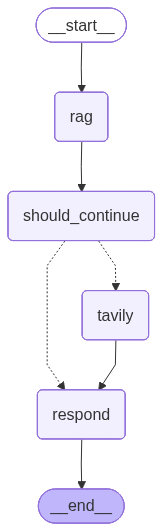

In [71]:
# Display the agent graph
try:
    from IPython.display import display, Image
    display(Image(health_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nAgent structure:")
    print(health_agent.get_graph().draw_ascii())

## Task 5: Testing each retriever

### Retrieval (Naive)



In [60]:
# Retrieval
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 10})

### Augmented

In [61]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

### Generation

In [62]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4o-mini")

### LCEL RAG Chain

In [73]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter

naive_retrieval_chain = (
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [74]:
naive_retrieval_chain.invoke({"question" : "Is MRI covered under my plan?"})["response"].content

'Yes, MRI is covered under your plan. The cost includes a $50 copay per test, followed by a 40% coinsurance. Please ensure to check the details or any limitations in your specific plan document.'

#### 5.2: Testing all retrievers — BM25, Compression, Multi-Query, Parent Document, Ensemble, Semantic


In [81]:
# 5.2 BM25
from langchain_community.retrievers import BM25Retriever
bm25_retriever = BM25Retriever.from_documents(health_benefits_docs)
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

# 5.3 Contextual Compression (retriever + CohereRerank, no ContextualCompressionRetriever)
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_cohere import CohereRerank

class CompressionRetriever(BaseRetriever):
    base_retriever: BaseRetriever
    compressor: CohereRerank

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun | None = None) -> list[Document]:
        docs = self.base_retriever.invoke(query)
        if not docs:
            return []
        return self.compressor.compress_documents(docs, query)

compressor = CohereRerank(model="rerank-v3.5", top_n=6)
compression_retriever = CompressionRetriever(base_retriever=naive_retriever, compressor=compressor)
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

# 5.4 Multi-Query (custom: LLM generates query variations, then retrieve and merge)
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.language_models import BaseLanguageModel
from langchain_core.prompts import ChatPromptTemplate

MULTI_QUERY_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "Generate 3 different versions of the user question for document retrieval. Return one question per line, no numbering."),
    ("human", "{question}"),
])

class MultiQueryRetriever(BaseRetriever):
    base_retriever: BaseRetriever
    llm: BaseLanguageModel
    num_queries: int = 3

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun | None = None) -> list[Document]:
        chain = MULTI_QUERY_PROMPT | self.llm
        out = chain.invoke({"question": query})
        text = out.content if hasattr(out, "content") else str(out)
        queries = [q.strip() for q in text.strip().split("\n") if q.strip()][: self.num_queries]
        if not queries:
            queries = [query]
        seen = set()
        result: list[Document] = []
        for q in queries:
            for doc in self.base_retriever.invoke(q):
                key = (doc.page_content[:200], doc.metadata.get("source", ""))
                if key not in seen:
                    seen.add(key)
                    result.append(doc)
        return result

multi_query_retriever = MultiQueryRetriever(base_retriever=naive_retriever, llm=chat_model)
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

# 5.5 Parent Document (custom: child chunks in vector store, parent docs in dict, return parents)
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models
from langchain_qdrant import QdrantVectorStore
import uuid

parent_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

_pd_client = QdrantClient(location=":memory:")
_pd_client.create_collection(collection_name="benefits_parent_child", vectors_config=models.VectorParams(size=3072, distance=models.Distance.COSINE))
parent_document_vectorstore = QdrantVectorStore(collection_name="benefits_parent_child", embedding=embeddings, client=_pd_client)

parent_store: dict[str, Document] = {}
child_docs_for_vectorstore: list[Document] = []
for doc in raw_docs:
    parents = parent_splitter.split_documents([doc])
    for p in parents:
        parent_id = str(uuid.uuid4())
        p.metadata["parent_id"] = parent_id
        parent_store[parent_id] = p
        children = child_splitter.split_documents([p])
        for c in children:
            c.metadata["parent_id"] = parent_id
            child_docs_for_vectorstore.append(c)
parent_document_vectorstore.add_documents(child_docs_for_vectorstore)

class ParentDocumentRetriever(BaseRetriever):
    vectorstore: QdrantVectorStore
    parent_store: dict
    k: int = 10

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun | None = None) -> list[Document]:
        child_docs = self.vectorstore.similarity_search(query, k=self.k)
        parent_ids = list({d.metadata.get("parent_id") for d in child_docs if d.metadata.get("parent_id")})
        return [self.parent_store[pid] for pid in parent_ids if pid in self.parent_store]

parent_document_retriever = ParentDocumentRetriever(vectorstore=parent_document_vectorstore, parent_store=parent_store)
parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

# 5.6 Ensemble (custom: RRF merge of multiple retrievers)
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document

def _doc_key(d: Document) -> tuple:
    return (d.page_content[:300], d.metadata.get("source", ""))

class EnsembleRetriever(BaseRetriever):
    retrievers: list[BaseRetriever]
    weights: list[float] | None = None
    c: int = 60  # RRF constant
    k: int = 20  # max docs to return

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun | None = None) -> list[Document]:
        weights = self.weights or [1.0 / len(self.retrievers)] * len(self.retrievers)
        all_docs: list[list[Document]] = []
        for r in self.retrievers:
            docs = r.invoke(query)
            all_docs.append(docs if isinstance(docs, list) else list(docs))
        rrf_scores: dict[tuple, float] = {}
        doc_by_key: dict[tuple, Document] = {}
        for retriever_docs, w in zip(all_docs, weights):
            for rank, doc in enumerate(retriever_docs, start=1):
                key = _doc_key(doc)
                rrf_scores[key] = rrf_scores.get(key, 0.0) + w / (self.c + rank)
                if key not in doc_by_key:
                    doc_by_key[key] = doc
        sorted_keys = sorted(rrf_scores.keys(), key=lambda k: rrf_scores[k], reverse=True)[: self.k]
        return [doc_by_key[k] for k in sorted_keys]

retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
ensemble_retriever = EnsembleRetriever(retrievers=retriever_list, weights=[1/len(retriever_list)]*len(retriever_list))
ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

# 5.7 Semantic Chunking
from langchain_experimental.text_splitter import SemanticChunker
semantic_chunker = SemanticChunker(embeddings, breakpoint_threshold_type="percentile")
semantic_documents = semantic_chunker.split_documents(raw_docs)
semantic_vectorstore = QdrantVectorStore.from_documents(semantic_documents, embeddings, location=":memory:", collection_name="benefits_semantic_chunks")
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k": 10})
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
print("All 6 retrievers and LCEL chains defined (BM25, Compression, Multi-Query, Parent Document, Ensemble, Semantic).")


All 6 retrievers and LCEL chains defined (BM25, Compression, Multi-Query, Parent Document, Ensemble, Semantic).


In [82]:
# Ask the same question to all retrievers and output each answer
QUESTION = "Is MRI covered under my plan?"
chains = [
    ("Naive", naive_retrieval_chain),
    ("BM25", bm25_retrieval_chain),
    ("Compression", contextual_compression_retrieval_chain),
    ("Multi-Query", multi_query_retrieval_chain),
    ("Parent Document", parent_document_retrieval_chain),
    ("Ensemble", ensemble_retrieval_chain),
    ("Semantic", semantic_retrieval_chain),
]
for name, chain in chains:
    out = chain.invoke({"question": QUESTION})
    content = out["response"].content if hasattr(out["response"], "content") else str(out["response"])
    print(f"--- {name} ---")
    print(content)
    print()

--- Naive ---
Yes, an MRI is covered under your plan. The document indicates that for imaging services, including MRIs, there is a $50 copay per test and a 40% coinsurance after that. It’s important to note that preauthorization may be required, and failing to obtain it could result in a reduction of benefits.

--- BM25 ---
I don't know.

--- Compression ---
Yes, MRI is covered under your plan. There is a $50 copay per test and then a 40% coinsurance applies.

--- Multi-Query ---
Yes, MRI services are covered under your plan, but there is a $50 copay per test and a 40% coinsurance for imaging tests, which includes MRIs. Additionally, it is important to note that preauthorization is required, and failing to obtain this may result in a reduction in benefits.

--- Parent Document ---
Yes, MRI (Magnetic Resonance Imaging) is covered under your plan. The document states that imaging services, including MRIs, are subject to a $50 copayment for network providers and 40% coinsurance for out-of

### Task 6: Eval Metrics

Below we **only** test the **LangGraph** (`health_agent`) with RAGAS metrics (faithfulness, context_precision, context_recall).

1. Run the **RAGAS 10-questions generator** cell below to set `eval_questions` and `eval_ground_truth`.
2. Run the **LangGraph (health_agent)** evaluation cell to score the graph on those questions.


In [86]:
# Ensure rapidfuzz is installed (required by RAGAS TestsetGenerator). Run this cell once if you get ModuleNotFoundError.
import sys
import subprocess
try:
    import rapidfuzz
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rapidfuzz"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    import rapidfuzz
print("rapidfuzz OK")

rapidfuzz OK


In [88]:
# Generate 10 eval questions dynamically with RAGAS (from raw_docs)
from datasets import Dataset

try:
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
except ImportError:
    from ragas.testset import LangchainLLMWrapper, LangchainEmbeddingsWrapper

try:
    from ragas.testset import TestsetGenerator
except ImportError:
    from ragas.testset.generator import TestsetGenerator

generator_llm = LangchainLLMWrapper(chat_model)
generator_embeddings = LangchainEmbeddingsWrapper(embeddings)
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

ragas_testset = generator.generate_with_langchain_docs(raw_docs, testset_size=10)
df = ragas_testset.to_pandas()
eval_questions = (df["user_input"] if "user_input" in df.columns else df["question"]).tolist()
eval_ground_truth = (df["reference"] if "reference" in df.columns else df["ground_truth"]).tolist()
eval_questions, eval_ground_truth = eval_questions[:10], eval_ground_truth[:10]

print(f"Generated {len(eval_questions)} RAGAS eval questions.")
for i, (q, gt) in enumerate(zip(eval_questions, eval_ground_truth), 1):
    print(f"  {i}. {q}")
    print(f"     Ground truth: {gt}")


C:\Users\bremi\AppData\Local\Temp\ipykernel_9972\2062419326.py:15: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  generator_llm = LangchainLLMWrapper(chat_model)
C:\Users\bremi\AppData\Local\Temp\ipykernel_9972\2062419326.py:16: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = LangchainEmbeddingsWrapper(embeddings)
Applying EmbeddingExtractor:  12%|█▎        | 1/8 [00:00<00:03,  2.04it/s]Property 'summary_embedding' already exists in node '76c0eb'. Skipping!
Property 'summary_embedding' already exist

Generated 6 RAGAS eval questions.
  1. What type of coverage does Plan Option 1 provide according to the Summary of Benefits and Coverage?
     Ground truth: Plan Option 1 provides coverage for families and is classified as a PPO plan.
  2. What information does the Summary of Benefits and Coverage provide regarding Benefits and Coverage?
     Ground truth: The Summary of Benefits and Coverage (SBC) document provides information on what the health plan covers and what you pay for covered services. It helps you choose a health plan by showing the coverage details for the specified period.
  3. What is the out-of-pocket limit for family coverage in this health plan?
     Ground truth: The out-of-pocket limit for family coverage in this health plan is $5,000 for network providers and $8,000 for out-of-network providers.
  4. What is the out-of-pocket limit for a family under this health plan?
     Ground truth: The out-of-pocket limit for this plan is $5,000 for a family when using networ

In [89]:
# RAGAS evaluation: LangGraph (health_agent) — faithfulness, context_precision, context_recall
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, context_precision, context_recall

contexts_list = []
answers_list = []
for q in eval_questions:
    state = {"question": q, "rag_context": "", "rag_response": "", "tavily_result": "", "messages": []}
    result = health_agent.invoke(state)
    ctxs = [result["rag_context"]]
    if result.get("tavily_result"):
        ctxs.append(result["tavily_result"])
    contexts_list.append(ctxs)
    final_msg = result["messages"][-1] if result.get("messages") else None
    answers_list.append(getattr(final_msg, "content", None) or str(final_msg) if final_msg else "")

eval_data = {
    "question": eval_questions,
    "contexts": contexts_list,
    "answer": answers_list,
    "ground_truth": eval_ground_truth,
}
dataset_agent = Dataset.from_dict(eval_data)
result_agent = evaluate(dataset_agent, metrics=[faithfulness, context_precision, context_recall])
print("LangGraph (health_agent) — RAGAS metrics:")
display(result_agent.to_pandas())

C:\Users\bremi\AppData\Local\Temp\ipykernel_9972\1545633797.py:4: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, context_precision, context_recall
C:\Users\bremi\AppData\Local\Temp\ipykernel_9972\1545633797.py:4: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, context_precision, context_recall
C:\Users\bremi\AppData\Local\Temp\ipykernel_9972\1545633797.py:4: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import contex

LangGraph (health_agent) — RAGAS metrics:


,user_input,retrieved_contexts,response,reference,faithfulness,context_precision,context_recall
0,What type of coverage does Plan Option 1 provi...,[Summary of Benefits and Coverage: What this P...,Plan Option 1 offers coverage under a PPO (Pre...,Plan Option 1 provides coverage for families a...,1.000000,1.0,1.0
1,What information does the Summary of Benefits ...,[Summary of Benefits and Coverage: What this P...,The Summary of Benefits and Coverage (SBC) pro...,The Summary of Benefits and Coverage (SBC) doc...,1.000000,1.0,1.0
2,What is the out-of-pocket limit for family cov...,[services? \nYes. $300 for prescription drug \...,The out-of-pocket limit for family coverage in...,The out-of-pocket limit for family coverage in...,0.666667,1.0,1.0
3,What is the out-of-pocket limit for a family u...,"[family members in this plan, they have to mee...",The out-of-pocket limit for a family under thi...,"The out-of-pocket limit for this plan is $5,00...",1.000000,1.0,1.0
4,How much will Joe pay for managing his type 2 ...,[(a year of routine in-network care of a well-...,"Joe will pay a total of $2,360 for managing hi...","Joe would pay a total of $2,360 for managing h...",1.000000,1.0,1.0
5,Wut is the total cost Mia has to pay for her s...,"[Total Example Cost $12,800 \nIn this example,...","Based on internal policy documents, Mia's tota...",The total Mia would pay for her simple fractur...,0.250000,1.0,1.0
